Sample Dataset
   Customer_ID  Age  Monthly_Visits  Purchase_Amount  Satisfaction_Score  \
0            1   56               7              125                  10   
1            2   46               2              203                   2   
2            3   32               3              705                   5   
3            4   60              17              484                   5   
4            5   25               5              135                   6   

   Orders  Revenue  Returns  
0      13     1625        0  
1      10     2030        0  
2       3     2115        2  
3       3     1452        2  
4       5      675        3  

===== STATISTICAL ANALYSIS =====
                        Mean  Median      Std_Dev
Customer_ID          100.500   100.5    57.879185
Age                   41.570    42.0    13.715527
Monthly_Visits         9.295     8.0     6.015723
Purchase_Amount      525.890   528.5   280.178278
Satisfaction_Score     5.185     5.0     2.881369
Orders        

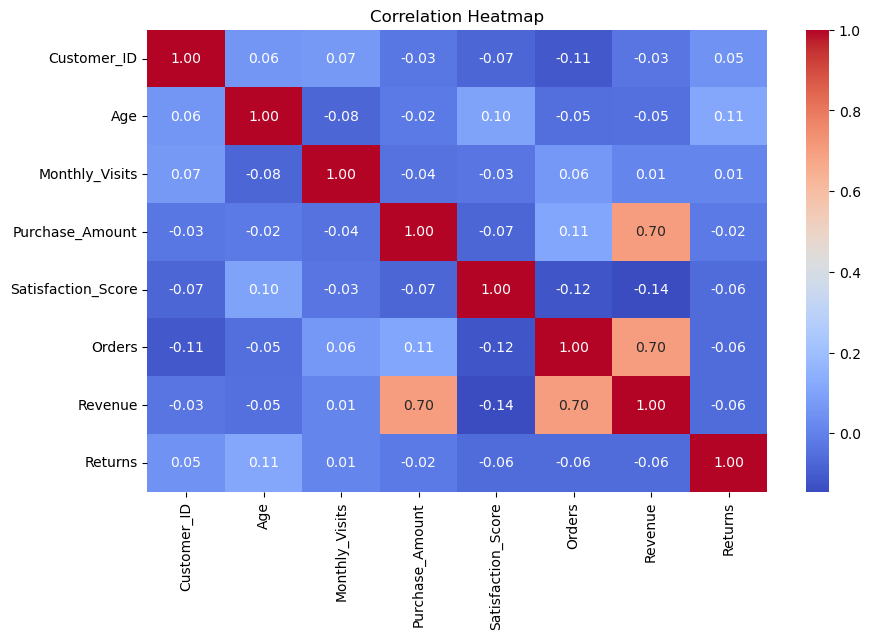


===== BUSINESS KPIs =====
Total Revenue: $805,166.00
Average Order Value: $525.89
Total Orders: 1486
Return Rate: 20.19%

===== CUSTOMER BEHAVIOR =====
Number of High Value Customers: 76

Average Satisfaction Score: 5.18


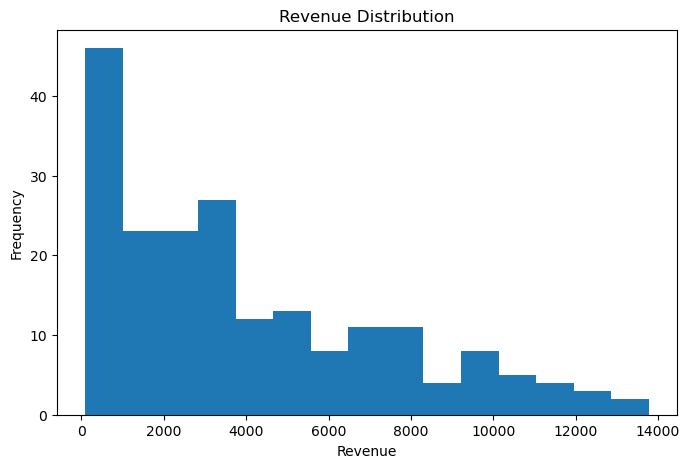

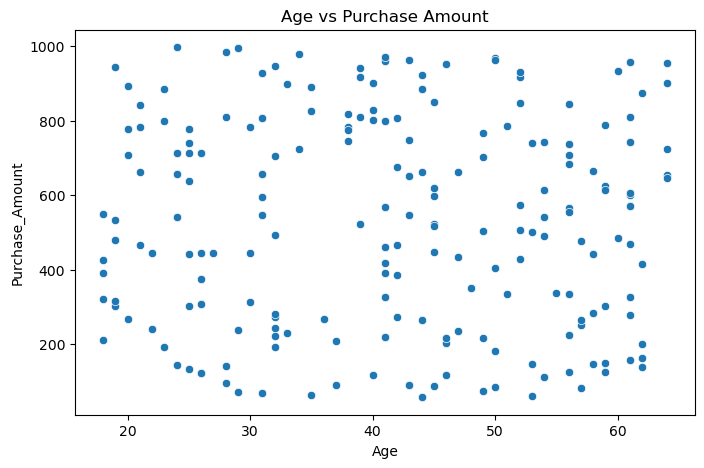

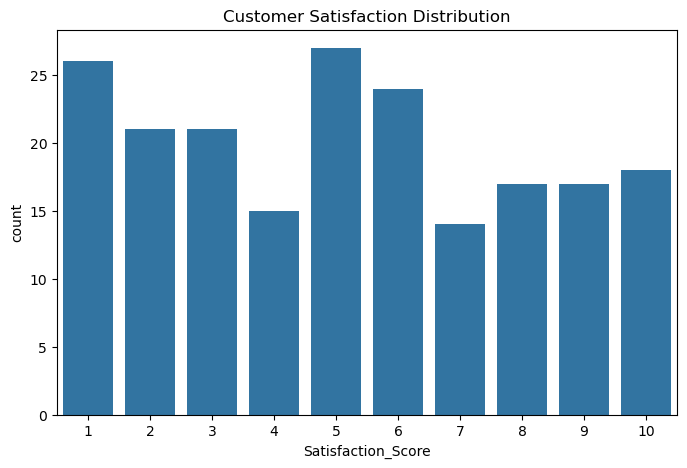

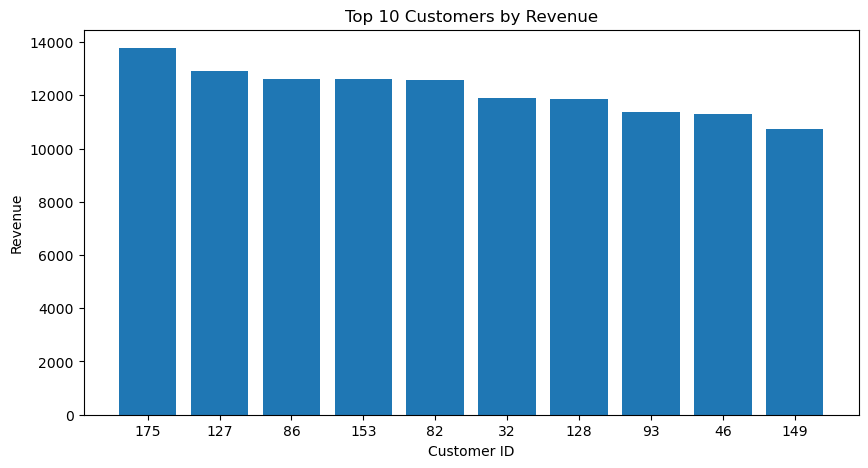


===== DASHBOARD =====
                 Metric          Value
0         Total Revenue  805166.000000
1   Average Order Value     525.890000
2          Total Orders    1486.000000
3       Return Rate (%)      20.188425
4  Average Satisfaction       5.185000

===== BUSINESS INSIGHTS =====
- High return rate detected. Investigate product quality.
- Customers with higher orders generate significantly more revenue.
- High-value customers should be targeted with loyalty programs.
- Satisfaction scores can be used to improve customer retention.
- Revenue concentration among top customers suggests VIP opportunities.


In [2]:
# ==========================================
# WEEK 10 PROJECT
# Statistical Analysis & Business KPIs
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------
# Step 1: Create Dataset
# ------------------------------------------

np.random.seed(42)

n = 200

data = {
    "Customer_ID": range(1, n+1),
    "Age": np.random.randint(18, 65, n),
    "Monthly_Visits": np.random.randint(1, 20, n),
    "Purchase_Amount": np.random.randint(50, 1000, n),
    "Satisfaction_Score": np.random.randint(1, 11, n),
    "Orders": np.random.randint(1, 15, n)
}

df = pd.DataFrame(data)

# Business metrics
df["Revenue"] = df["Purchase_Amount"] * df["Orders"]
df["Returns"] = np.random.randint(0, 4, n)

print("Sample Dataset")
print(df.head())

# ------------------------------------------
# Step 2: Statistical Analysis
# ------------------------------------------

print("\n===== STATISTICAL ANALYSIS =====")

stats = pd.DataFrame({
    "Mean": df.mean(numeric_only=True),
    "Median": df.median(numeric_only=True),
    "Std_Dev": df.std(numeric_only=True)
})

print(stats)

# ------------------------------------------
# Step 3: Correlation Analysis
# ------------------------------------------

print("\n===== CORRELATION MATRIX =====")

corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# ------------------------------------------
# Step 4: Business KPIs
# ------------------------------------------

total_revenue = df["Revenue"].sum()
avg_order_value = df["Purchase_Amount"].mean()
total_orders = df["Orders"].sum()
return_rate = (df["Returns"].sum() / total_orders) * 100

print("\n===== BUSINESS KPIs =====")
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Average Order Value: ${avg_order_value:.2f}")
print(f"Total Orders: {total_orders}")
print(f"Return Rate: {return_rate:.2f}%")

# ------------------------------------------
# Step 5: Customer Behavior Analysis
# ------------------------------------------

high_value_customers = df[df["Revenue"] > df["Revenue"].mean()]

print("\n===== CUSTOMER BEHAVIOR =====")
print("Number of High Value Customers:",
      len(high_value_customers))

print("\nAverage Satisfaction Score:",
      round(df["Satisfaction_Score"].mean(),2))

# ------------------------------------------
# Step 6: Trend Charts
# ------------------------------------------

# Revenue Distribution
plt.figure(figsize=(8,5))
plt.hist(df["Revenue"], bins=15)
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

# Age vs Purchase Amount
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,
                x="Age",
                y="Purchase_Amount")
plt.title("Age vs Purchase Amount")
plt.show()

# Satisfaction Score Distribution
plt.figure(figsize=(8,5))
sns.countplot(x="Satisfaction_Score", data=df)
plt.title("Customer Satisfaction Distribution")
plt.show()

# Top 10 Customers by Revenue
top10 = df.sort_values(
    by="Revenue",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))
plt.bar(top10["Customer_ID"].astype(str),
        top10["Revenue"])
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.show()

# ------------------------------------------
# Step 7: Dashboard Summary
# ------------------------------------------

dashboard = {
    "Total Revenue": total_revenue,
    "Average Order Value": avg_order_value,
    "Total Orders": total_orders,
    "Return Rate (%)": return_rate,
    "Average Satisfaction":
        df["Satisfaction_Score"].mean()
}

dashboard_df = pd.DataFrame(
    dashboard.items(),
    columns=["Metric", "Value"]
)

print("\n===== DASHBOARD =====")
print(dashboard_df)

# ------------------------------------------
# Step 8: Insight Report
# ------------------------------------------

print("\n===== BUSINESS INSIGHTS =====")

if return_rate > 10:
    print("- High return rate detected. Investigate product quality.")
else:
    print("- Return rate is under control.")

print("- Customers with higher orders generate significantly more revenue.")

print("- High-value customers should be targeted with loyalty programs.")

print("- Satisfaction scores can be used to improve customer retention.")

print("- Revenue concentration among top customers suggests VIP opportunities.")